In [1]:
import numpy as np
import matplotlib.pyplot as plt

Priset för en amerikansk option är:

$$\max_{t \leq \tau \leq T} E[e^{-r(\tau - t)} \max (K - S(\tau)), 0) \mid S(t) = s]$$

Om vi antar att vi kan "sälja" vår option vid de diskreta tiderna

$$0, \Delta t, 2 \Delta t, 3 \Delta t, \dots, T$$

och låtsas att vi ligger vid tidsintervallet:

$$(T - \Delta t, T)$$

Så kan vi teoretiskt inte att sälja vår option. Eftersom att den inte är såld så borde den följa:

$$f_t + r S f_S + \frac{1}{2} \sigma^2 S^2 f_{SS} = r f$$

under det tidsintervallet eftersom att vi inte kan sälja den. Men notera att den då borde följa en europeisk option:

$$f(T,s) = \max(K - s, 0)$$

(i det tidsintervallet). Så hur hittar vi det optimala $\tau$:et då? Vi gör det genom att diskterisera problemet, och använda oss av dynamical programming. Vi disktretiserar problemet genom att sätta:

$$f_A(n \Delta t, i \Delta S) \simeq \bar{f}_{n, i}$$

$$\bar{f}_{N,i} = \max (K - i \Delta S, 0)$$

Vi använder oss av central difference method för att beskriva PDE:

$$\partial_t f_A \simeq \frac{\bar{f}_{n,i} - \bar{f}_{n - 1,i}}{\Delta t}$$


$$\partial_S f_A \simeq \frac{\bar{f}_{n, i+1 } - \bar{f}_{n, i-1}}{2\Delta S}$$

$$\partial_{SS} f_A \simeq \frac{\bar{f}_{n, i+1} - 2 \bar{f}_{n, i } + \bar{f}_{n, i-1}}{(\Delta S)^2}$$

$$f_A \simeq \bar{f}_{n, i}$$

Vi skriver den som:



In [2]:
def european_option(params, S, T, steps):

  r = params['r']
  sigma = params['sigma']
  K = params['K']

  s0 = S['s0']
  sM = S['sM']
  t0 = T['t0']
  tN = T['tN']

  dt = steps['dt']
  dS = steps['dS']

  N = int((tN - t0) / dt)
  M = int((sM - s0) / dS)

  f = np.zeros((N + 1, M + 1))

  S_grid = s0 + np.arange(M + 1) * dS
  T_grid = t0 + np.arange(N + 1) * dt

  f[N, :] = np.maximum(K - S_grid, 0)

  for n in range(N + 1):
    t = t0 + n * dt
    f[n, 0] = np.maximum(K - s0, 0) * np.exp(-r * (tN - t))
    f[n, M] = 0

  S_i = S_grid[1:M]

  for n in range(N, 0, -1):

    a = 1 - r * dt - sigma**2 * (S_i**2 / dS**2) * dt
    b = 0.5 * (r * S_i / dS + sigma**2 * S_i**2 / dS**2) * dt
    c = 0.5 * (-r * S_i / dS + sigma**2 * S_i**2 / dS**2) * dt

    f[n - 1, 1:M] = (
        a * f[n, 1:M] +
        b * f[n, 2:M+1] +
        c * f[n, 0:M-1]
    )

  return f, S_grid, T_grid

In [3]:
params = {'r' : 2, 'sigma' : 0.5, 'K' : 40}
S = {'s0' : 0, 'sM' : 100}
T = {'t0' : 0, 'tN' : 10}
steps = {'dt' : 0.00001, 'dS' : 1}

In [127]:
f, t, s = european_option(params, S, T, steps)

Text(0.5, 0, 'f')

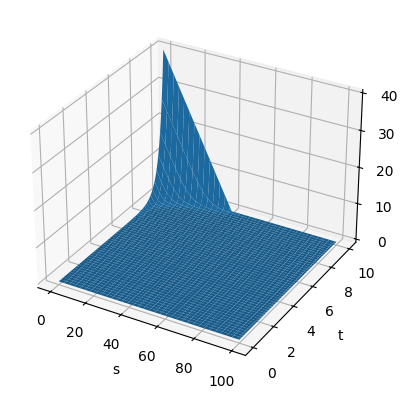

In [128]:
T_m, S_m = np.meshgrid(t, s)
ax = plt.axes(projection = "3d")
ax.plot_surface(T_m, S_m, f)
ax.set_xlabel("s")
ax.set_ylabel("t")
ax.set_zlabel("f")

In [4]:
def american_option(params, S, T, steps):

  r = params['r']
  sigma = params['sigma']
  K = params['K']

  s0 = S['s0']
  sM = S['sM']
  t0 = T['t0']
  tN = T['tN']

  dt = steps['dt']
  dS = steps['dS']

  N = int((tN - t0) / dt)
  M = int((sM - s0) / dS)

  f = np.zeros((N + 1, M + 1))

  S_grid = s0 + np.arange(M + 1) * dS
  T_grid = t0 + np.arange(N + 1) * dt

  f[N, :] = np.maximum(K - S_grid, 0)

  for n in range(N + 1):
    t = t0 + n * dt
    f[n, 0] = np.maximum(K - s0, 0) * np.exp(-r * (tN - t))
    f[n, M] = 0

  S_i = S_grid[1:M]

  for n in range(N, 0, -1):

    a = 1 - r * dt - sigma**2 * (S_i**2 / dS**2) * dt
    b = 0.5 * (r * S_i / dS + sigma**2 * S_i**2 / dS**2) * dt
    c = 0.5 * (-r * S_i / dS + sigma**2 * S_i**2 / dS**2) * dt

    vec = K - S_grid[1:M]

    f[n - 1, 1:M] = np.maximum(
        a * f[n, 1:M] +
        b * f[n, 2:M+1] +
        c * f[n, 0:M-1]
    , vec)

  return f, S_grid, T_grid

In [8]:
params = {'r' : 2, 'sigma' : 0.5, 'K' : 40}
S = {'s0' : 0, 'sM' : 100}
T = {'t0' : 0, 'tN' : 10}
steps = {'dt' : 0.0001, 'dS' : 1}

In [10]:
f_A, t, s = american_option(params, S, T, steps)

Text(0.5, 0, 'f')

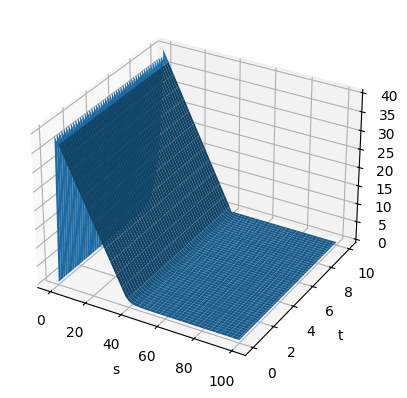

In [11]:
T_m, S_m = np.meshgrid(t, s)
ax = plt.axes(projection = "3d")
ax.plot_surface(T_m, S_m, f_A)
ax.set_xlabel("s")
ax.set_ylabel("t")
ax.set_zlabel("f")